In [ ]:
import warnings


warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", RuntimeWarning)

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module=r"squidpy\.pl\._spatial_utils"
)

In [1]:
#import spatialdata as sd
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq
import anndata as ad

import seaborn as sns
import pickle


from matplotlib.colors import ListedColormap


 
    

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: 

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
#%matplotlib inline
sc.settings.figdir = "fig4"
sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(8,8))


# dotplot of expression

In [3]:
FILE_NAME = "adata_combined_new.h5ad.final.filtered"
PATH2=f'/nfs/team298/ls34/adult_skin/final_adatas/{FILE_NAME}'
adata_5k=sc.read_h5ad(PATH2)
adata_5k=adata_5k[adata_5k.obs["tech"]=="xenium"]


def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata_5k.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata_5k.var_names]
    return LIST

 
 

In [4]:
CATEGORY="lvl5_annotation"
NICHE_COLUMN   = "niche19"
NICHE_COL=NICHE_COLUMN

In [5]:
sc.pp.normalize_total(adata_5k, target_sum=1e4)
sc.pp.log1p(adata_5k)

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


# Sebaceous gland composition

In [7]:
na_counts = (
    adata_5k.obs
    .groupby("sample_id")[NICHE_COLUMN]
    .apply(lambda x: x.isna().sum())
    .sort_values(ascending=False)
)

na_counts.head(5)


           

sample_id
3D_BK22_Lesional_baseline-A1                       0
3D_BK22_Lesional_baseline-A2                       0
Baseline_resolved_CE5-SKI-27-FO-1-S22-B1           0
Baseline_resolved_CE4-SKI-27-FO-1-S22_replicate    0
Baseline_resolved_CE4-SKI-27-FO-1-S22-B2           0
Name: niche19, dtype: int64

# e9f

Cell count for slide:  961

BK22_Lesional Baseline
Cell count for slide:  309

Lesional_CE4-SKI-27-FO-4-S22-A2
Cell count for slide:  360

BK51_wk8 Relapse
Cell count for slide:  113

BK25_Week 12


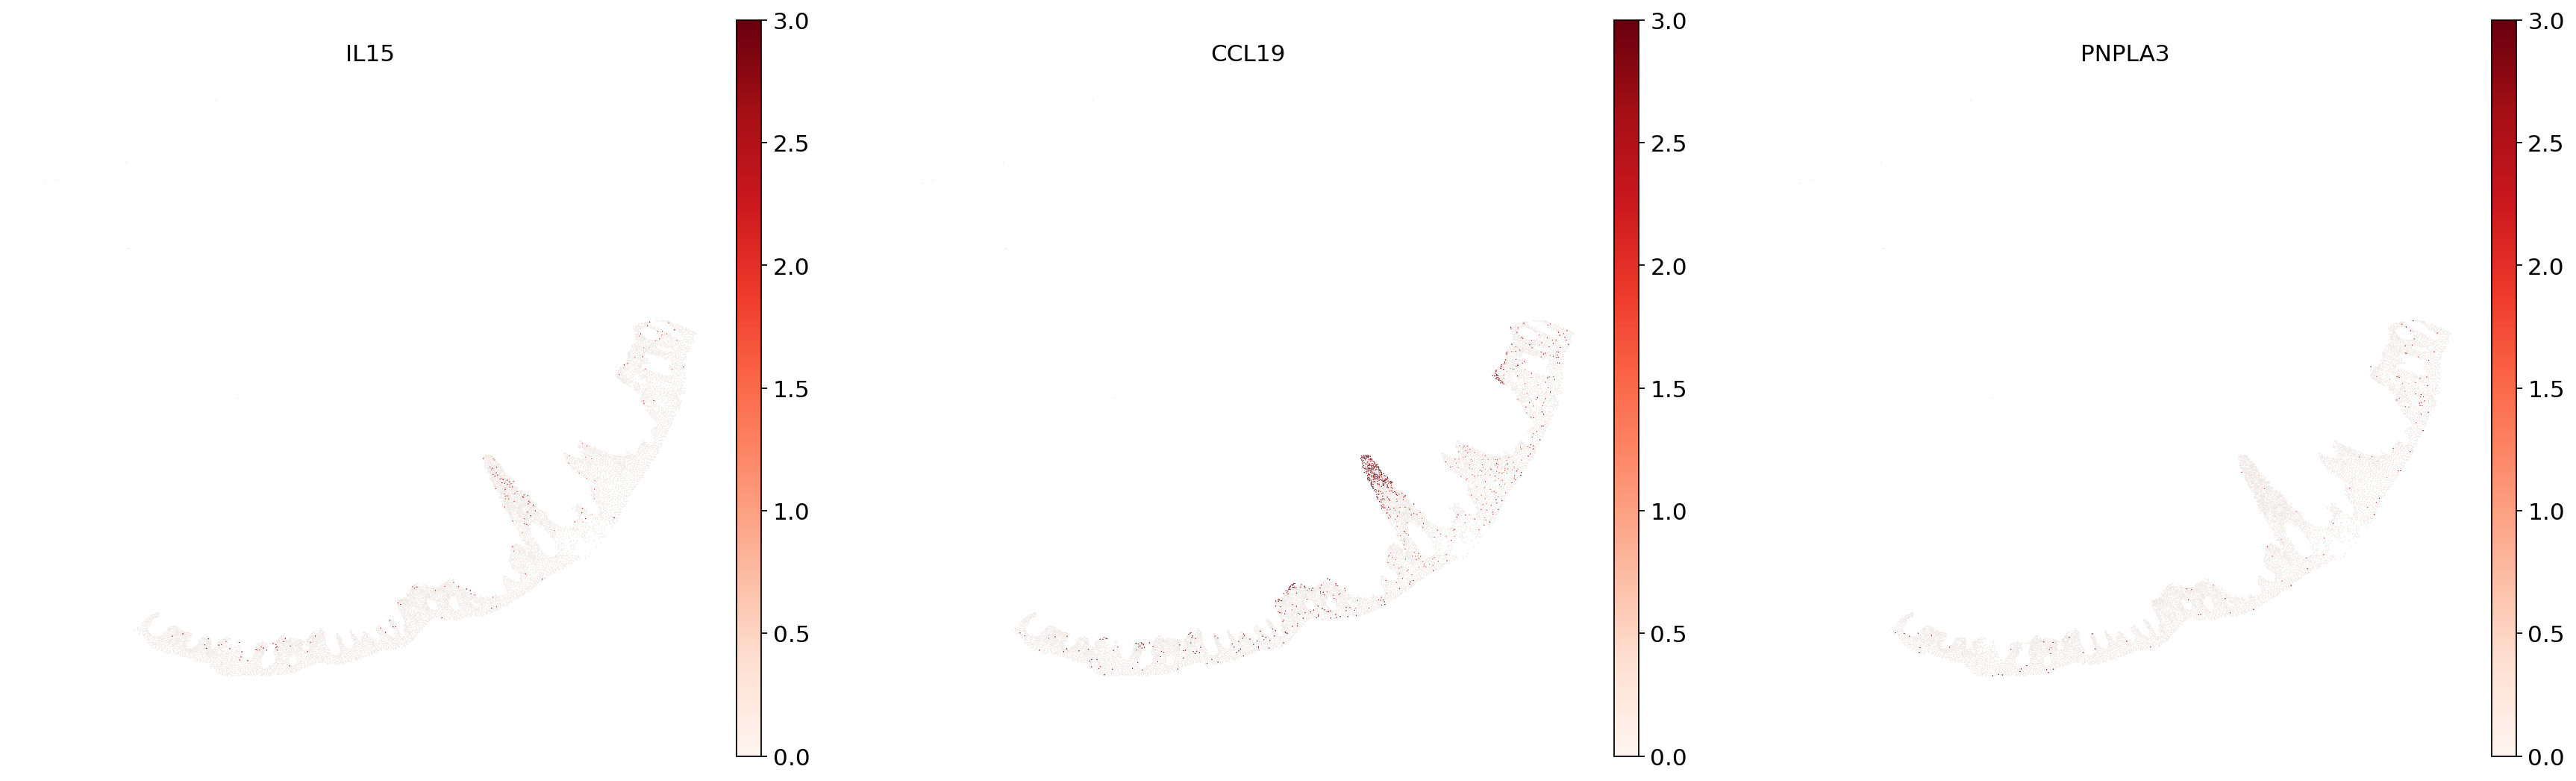

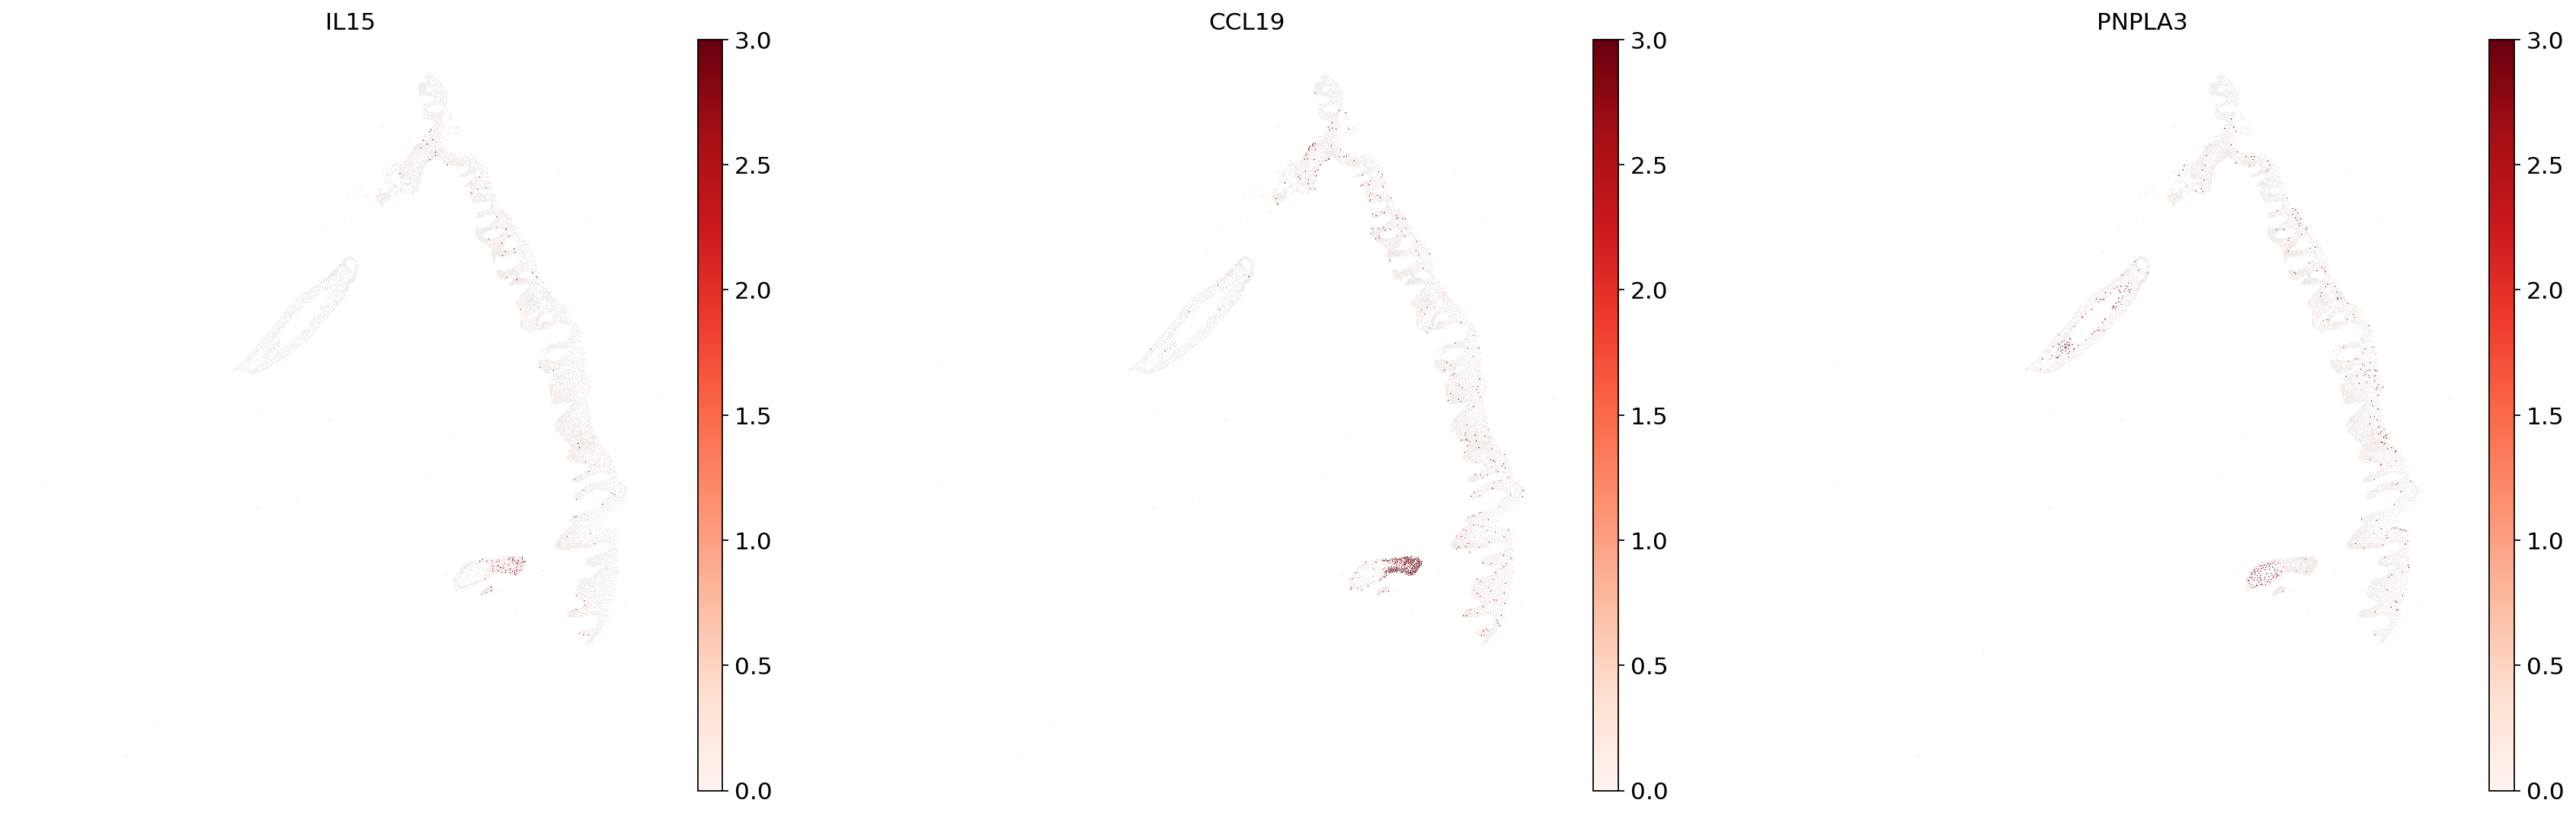

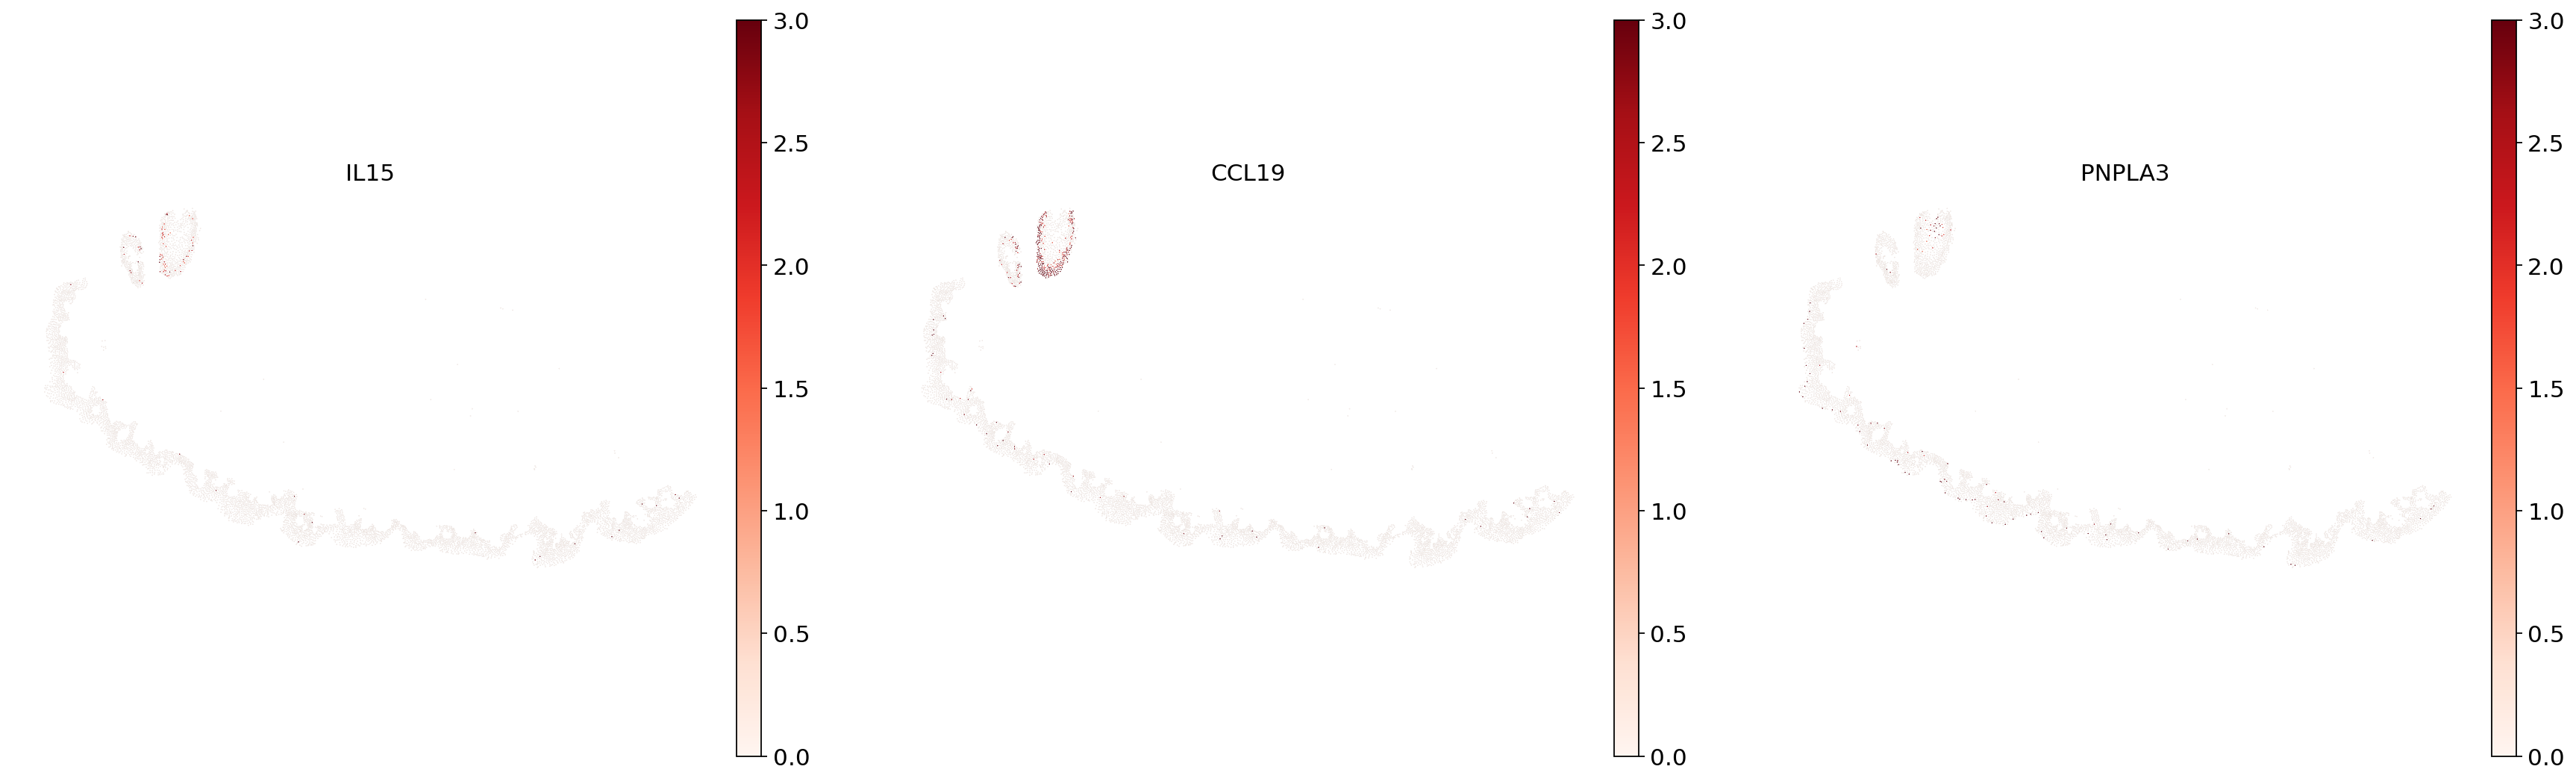

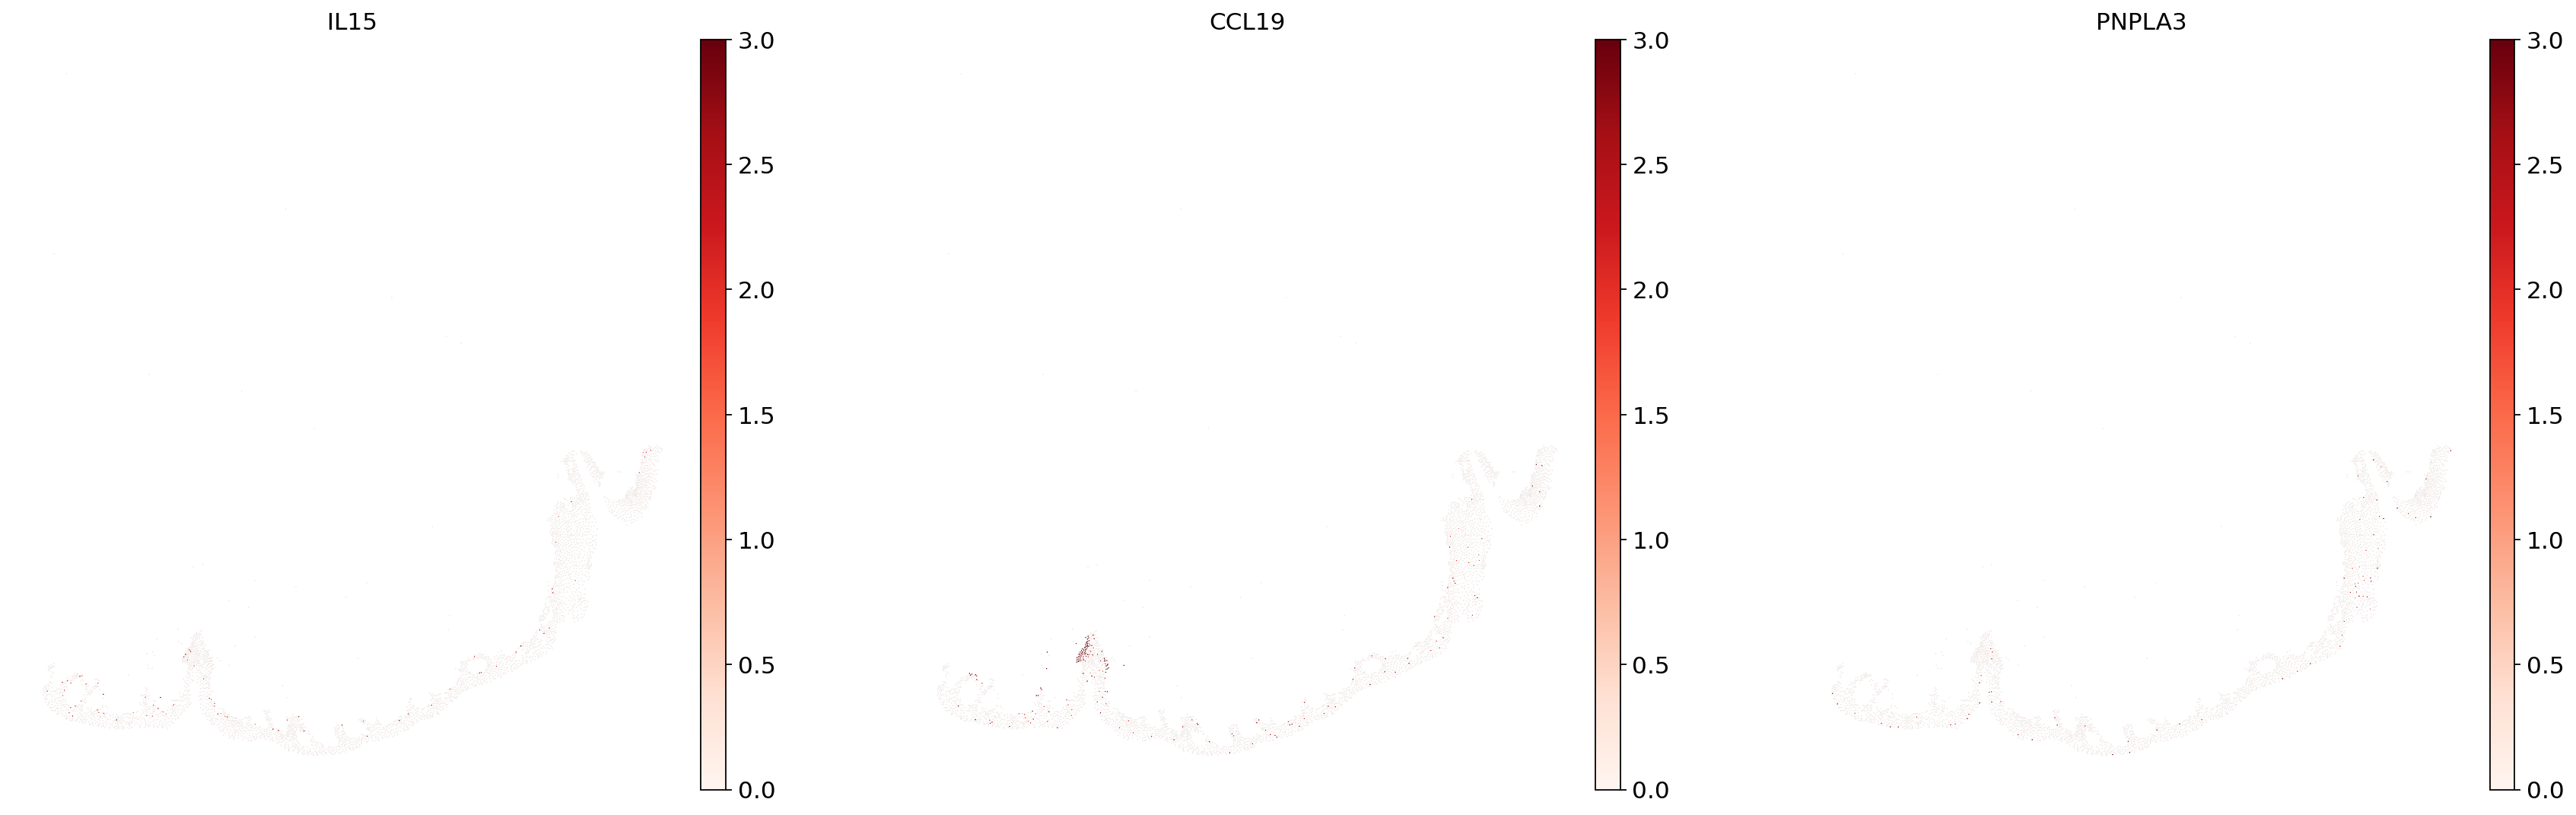

In [8]:
adata_5k_i = adata_5k[(adata_5k.obs["lvl5_annotation"].str.startswith("Seb"))|
                       (adata_5k.obs["lvl5_annotation"].str.startswith("KC"))|
                         (adata_5k.obs["niche19"].str.startswith("Seb"))]
                     

    
    
    
NICHE="Sebaceous_immune"


for i, DONOR_ID in enumerate(['BK22_Lesional Baseline',
 'Lesional_CE4-SKI-27-FO-4-S22-A2',
 'BK51_wk8 Relapse',
 'BK25_Week 12', 
                              #'BK21_Week 12' 
                             ]  ):
    adata_i = adata_5k_i[adata_5k_i.obs["info_id6"] == DONOR_ID]
    #print(adata_i.shape_)
    #print(i+1, "/", len(samples_to_keep))
    STATUS = adata_i.obs["Site_status"].unique()[0]
    TIMEPOINT = adata_i.obs["Timepoint"].unique()[0]
    DONOR = adata_i.obs["Sanger patient ID"].unique()[0]
    INFO_ID = list(adata_i.obs.info_id.unique())[0]
    niche_names_found = adata_i.obs[NICHE_COLUMN].unique()
   
    if NICHE in niche_names_found:
        adata_ii = adata_i[adata_i.obs[NICHE_COLUMN] == NICHE]
        CELL_COUNT = adata_ii.shape[0]
        print("Cell count for slide: ", CELL_COUNT)
        print()
        if CELL_COUNT > 10:
           # SEB_SAMPLES.append(DONOR_ID)
            print(DONOR_ID)
            sq.pl.spatial_scatter(
                adata_i,
                library_id="spatial",
                shape=None,
                color=['IL15', "CCL19", 'PNPLA3',],
                cmap="Reds", #=palette,
                size=1,
                vmax=3,
                title=['IL15', "CCL19", 'PNPLA3',],
                #title=f"{DONOR_ID}_{STATUS}_{TIMEPOINT}_{DONOR}_n={CELL_COUNT}",
                edgecolor='black',
                linewidth=0.01,
                legend_loc=None,
                #save=f"sebimmune_nicheonly_{DONOR_ID}.pdf"
                # ax=ax,
                # legend_loc="on data"
                save="supp9d_expression_labelled.pdf"

            )
       
            
            
#sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18, 18))


Cell count for slide:  961

Cell count for slide:  309

Cell count for slide:  360

Cell count for slide:  113



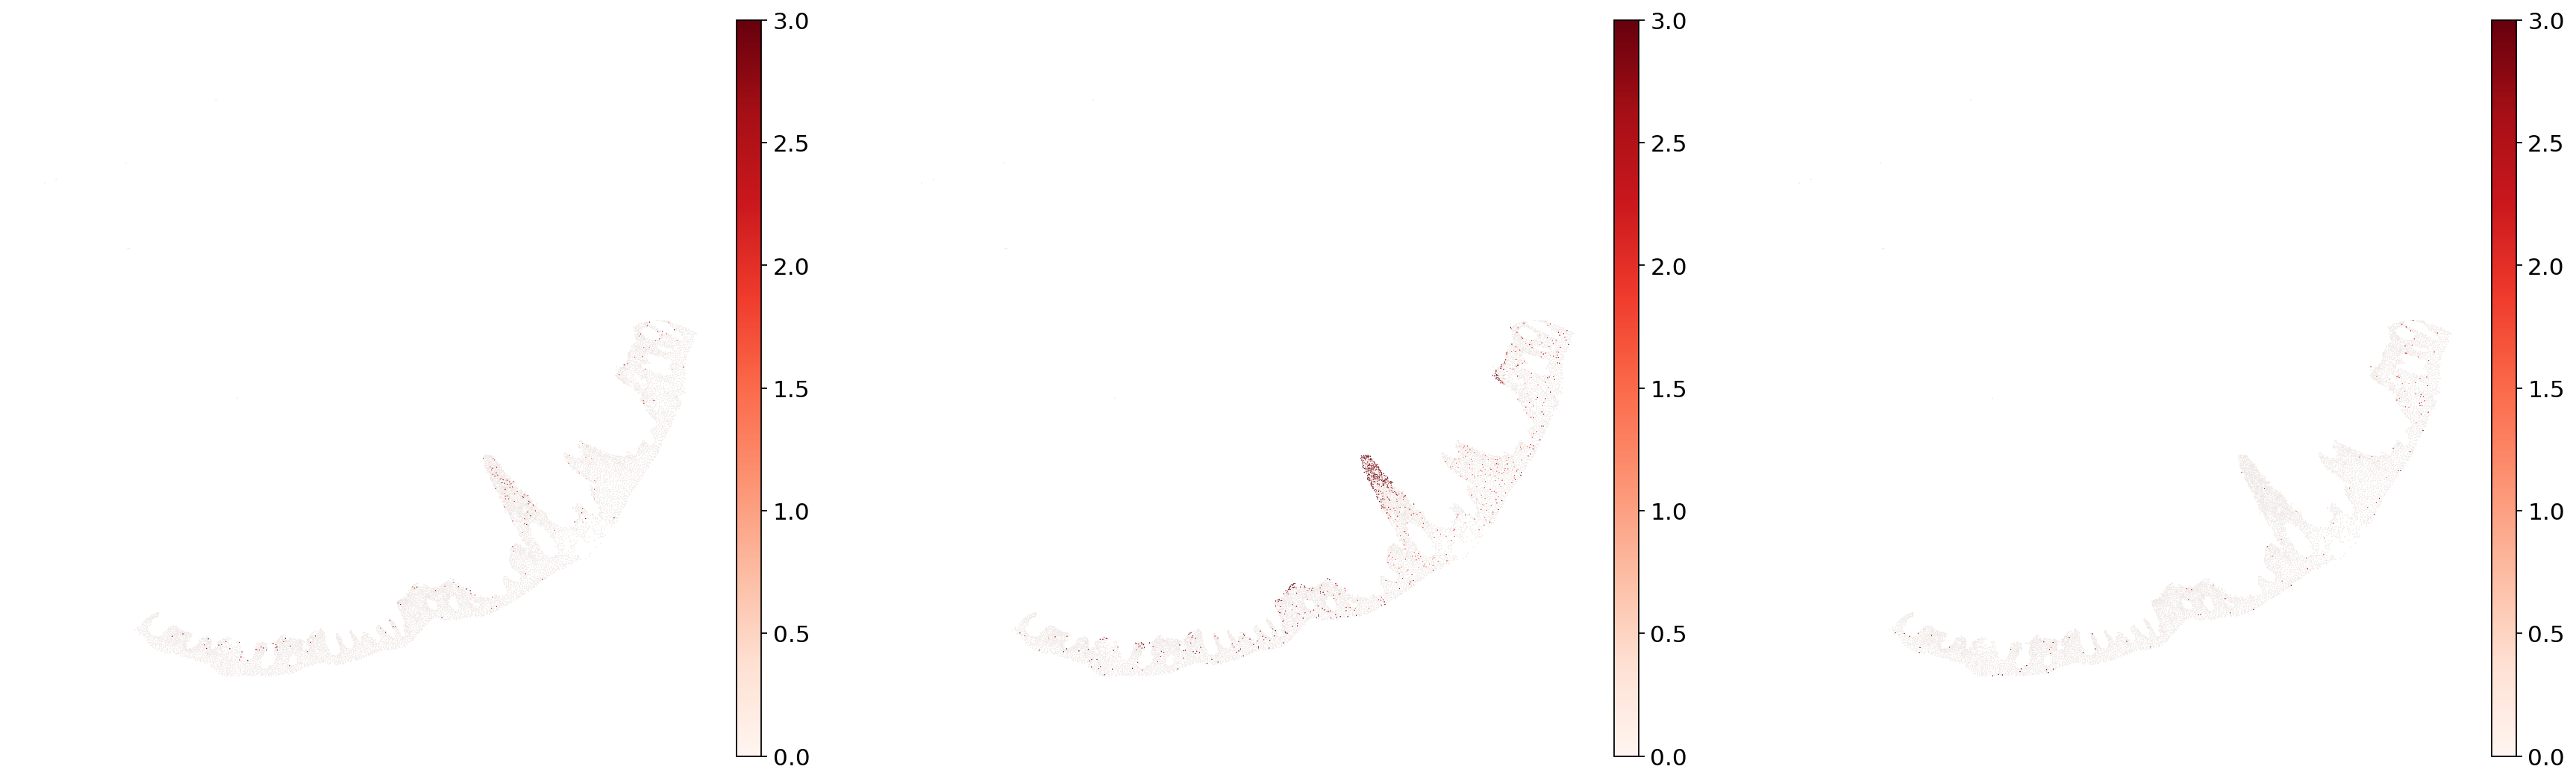

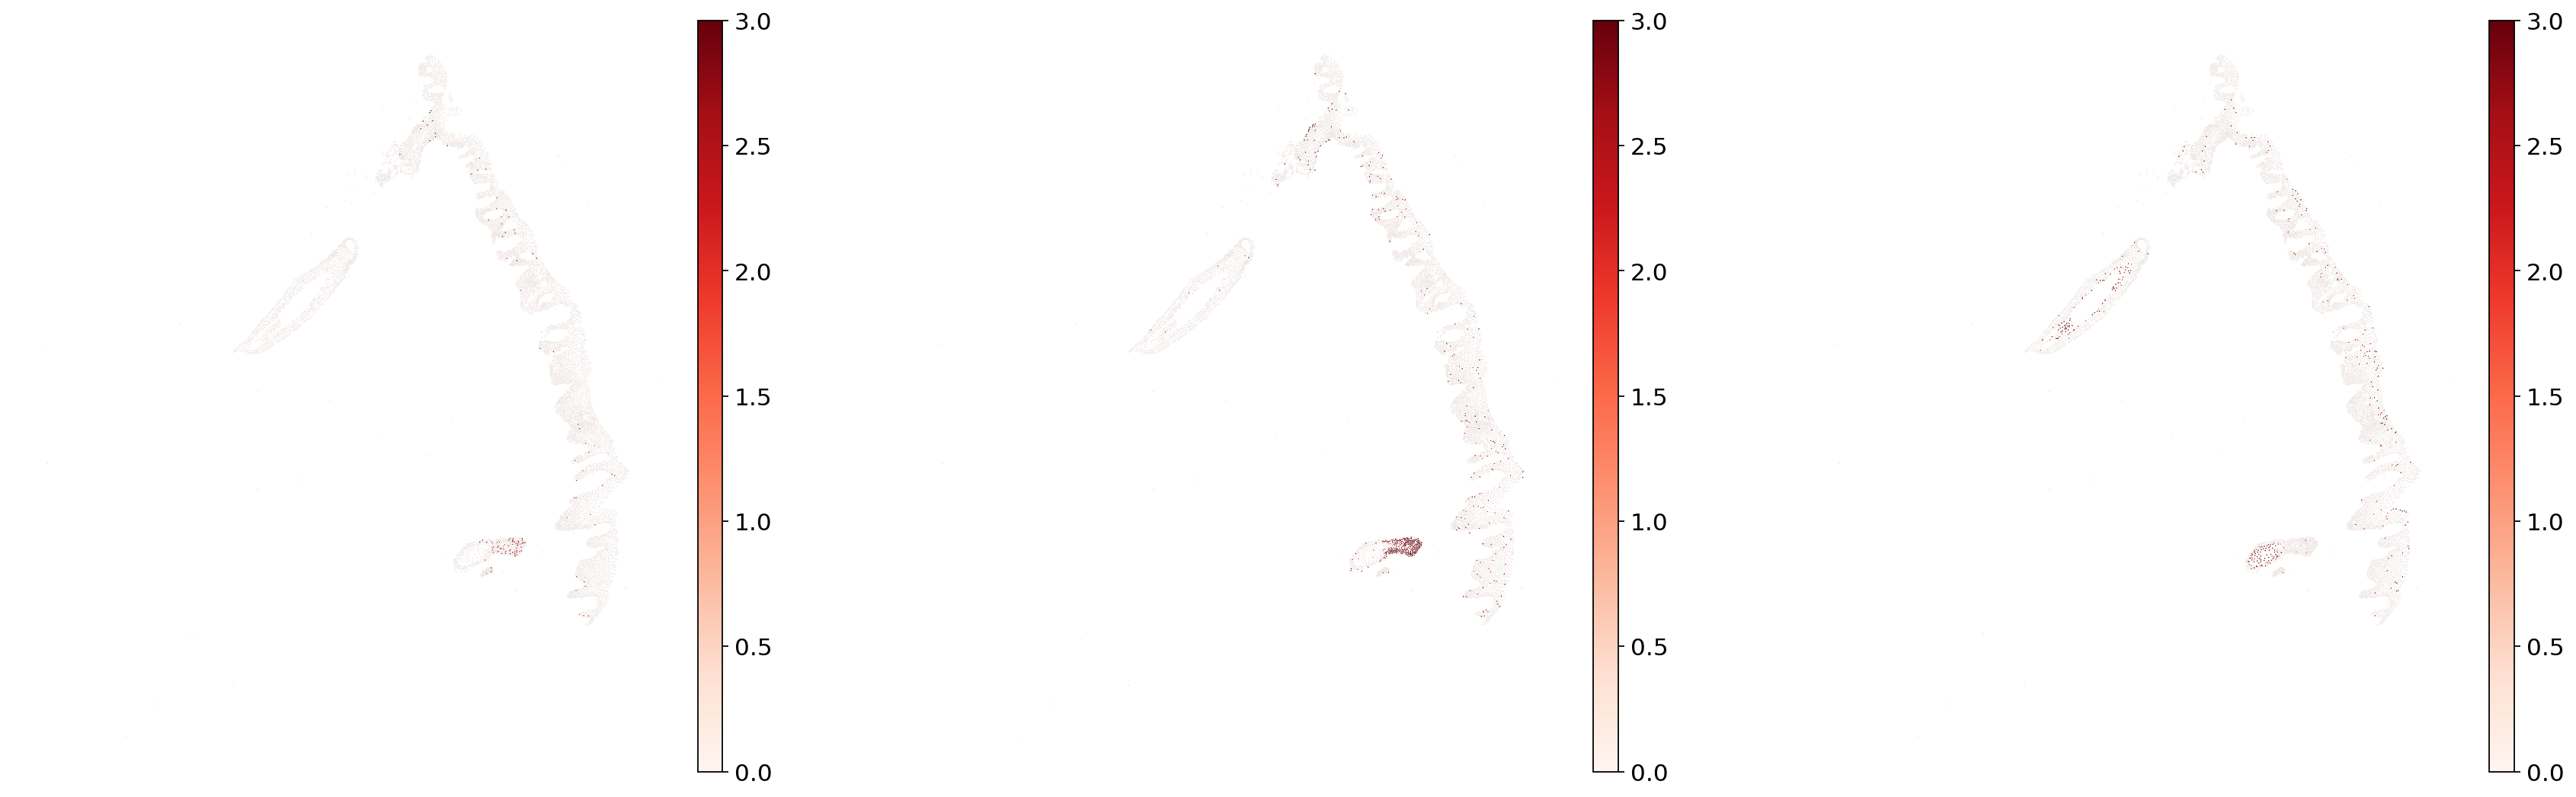

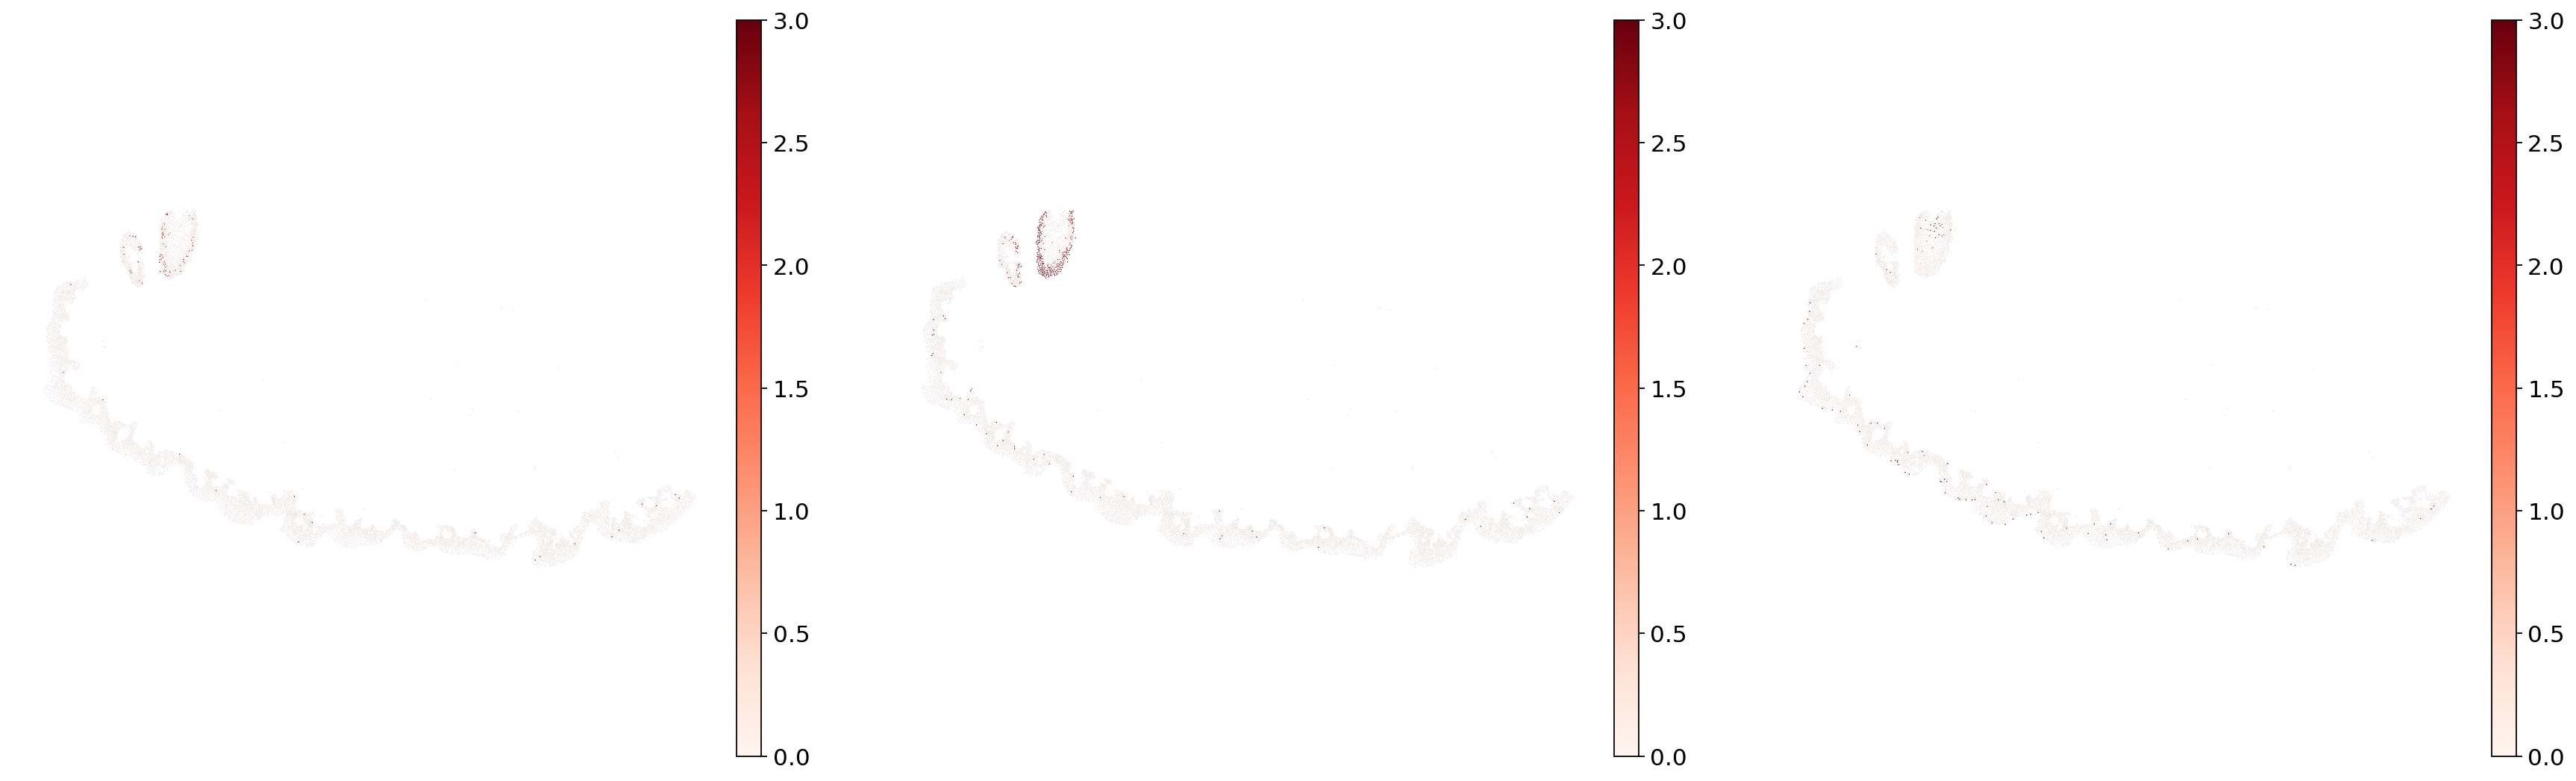

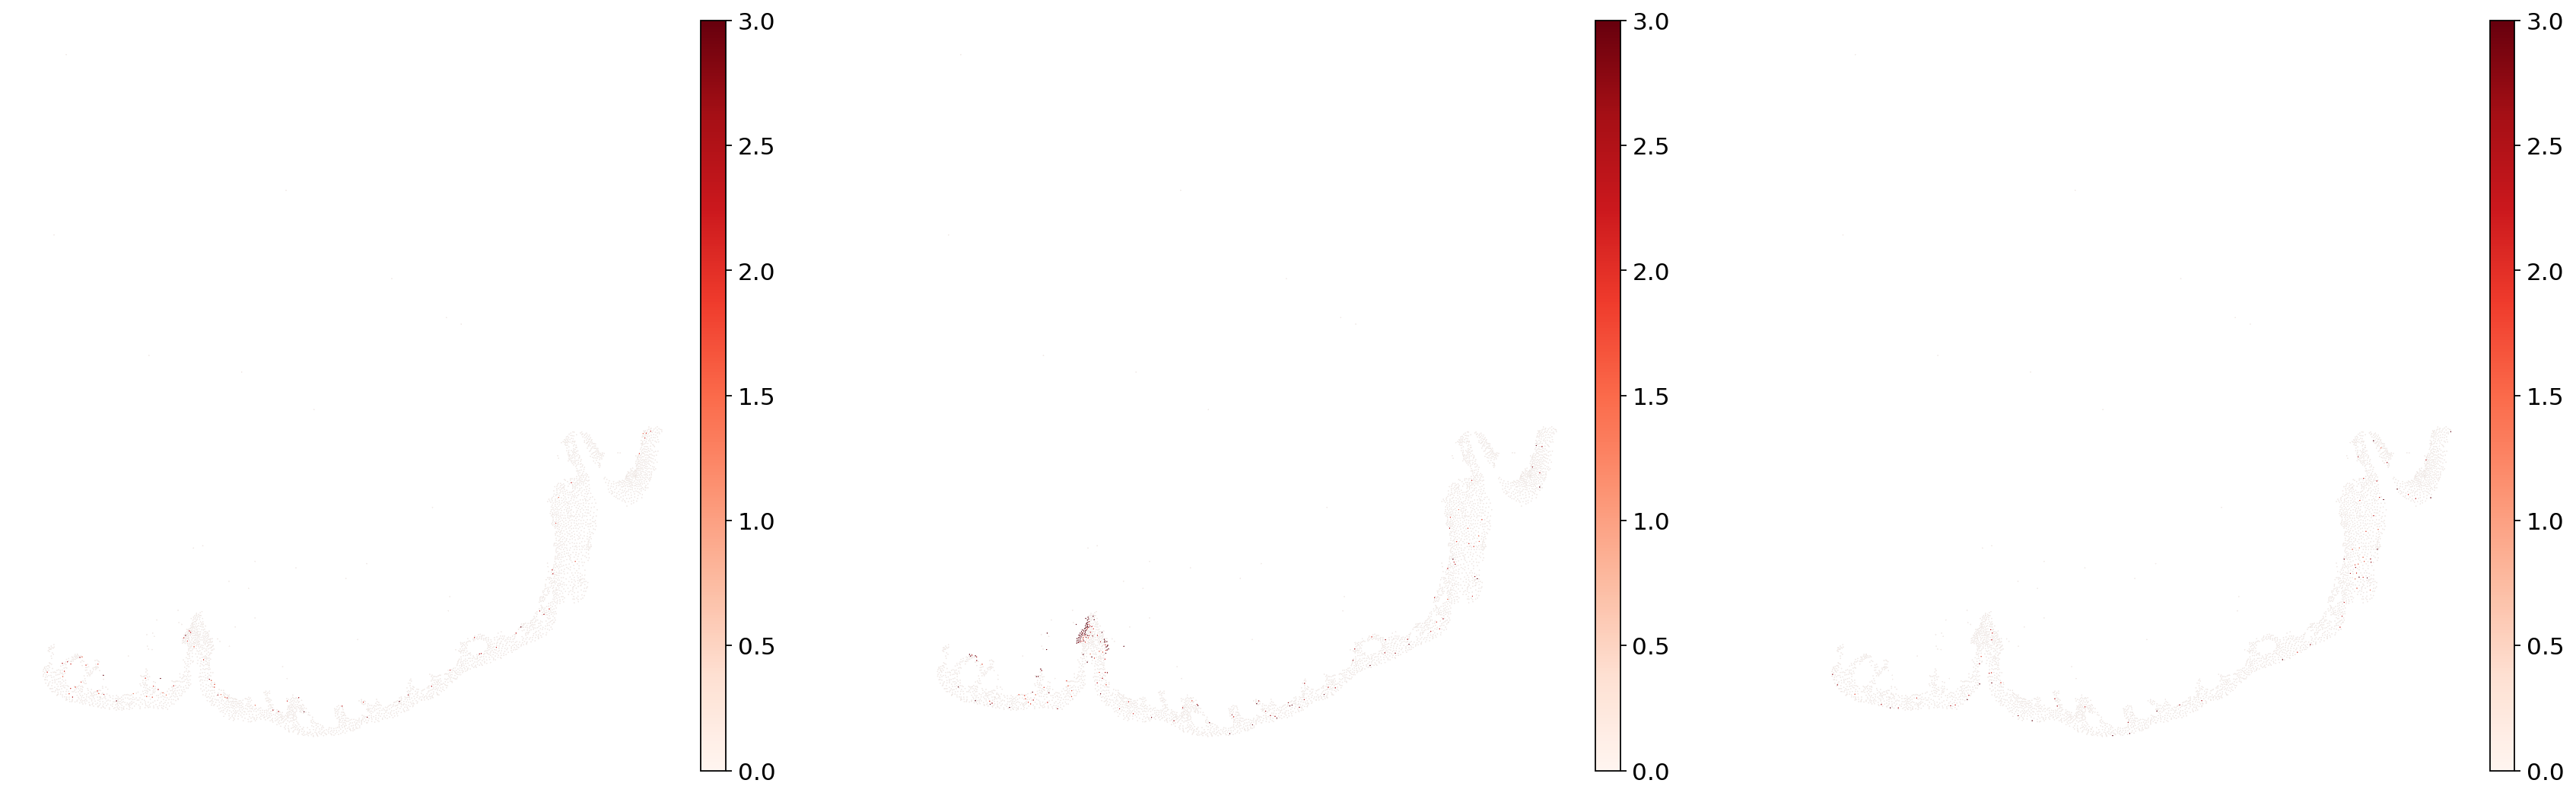

In [9]:
adata_5k_i = adata_5k[(adata_5k.obs["lvl5_annotation"].str.startswith("Seb"))|
                       (adata_5k.obs["lvl5_annotation"].str.startswith("KC"))|
                         (adata_5k.obs["niche19"].str.startswith("Seb"))]
                     

    
    
    
NICHE="Sebaceous_immune"


for i, DONOR_ID in enumerate(['BK22_Lesional Baseline',
 'Lesional_CE4-SKI-27-FO-4-S22-A2',
 'BK51_wk8 Relapse',
 'BK25_Week 12', 
                              #'BK21_Week 12' 
                             ]  ):
    adata_i = adata_5k_i[adata_5k_i.obs["info_id6"] == DONOR_ID]
    #print(adata_i.shape_)
    #print(i+1, "/", len(samples_to_keep))
    STATUS = adata_i.obs["Site_status"].unique()[0]
    TIMEPOINT = adata_i.obs["Timepoint"].unique()[0]
    DONOR = adata_i.obs["Sanger patient ID"].unique()[0]
    INFO_ID = list(adata_i.obs.info_id.unique())[0]
    niche_names_found = adata_i.obs[NICHE_COLUMN].unique()
   
    if NICHE in niche_names_found:
        adata_ii = adata_i[adata_i.obs[NICHE_COLUMN] == NICHE]
        CELL_COUNT = adata_ii.shape[0]
        print("Cell count for slide: ", CELL_COUNT)
        print()
        if CELL_COUNT > 10:

            sq.pl.spatial_scatter(
                    adata_i,
                    library_id="spatial",
                    shape=None,
                    color=['IL15', "CCL19", 'PNPLA3',],
                    cmap="Reds", #=palette,
                    size=1,
                    vmax=3,
                    title=['', '',''],
                    #title=f"{DONOR_ID}_{STATUS}_{TIMEPOINT}_{DONOR}_n={CELL_COUNT}",
                    edgecolor='black',
                    linewidth=0.01,
                    legend_loc=None,
                    #save=f"sebimmune_nicheonly_{DONOR_ID}.pdf"
                    # ax=ax,
                    # legend_loc="on data"
                    save="supp9d_expression.pdf"

                )

            
#sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18, 18))


In [10]:
import pickle

file_path = '/nfs/team298/ls34/color_for_adult_skin2.pkl'

with open(file_path, 'rb') as file:
    colors = pickle.load(file)

# Fig 4c 

0
Cell count for slide:  961

BK22_Lesional Baseline


/tmp/ipykernel_3387224/2133204752.py:37: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[NICHE_COLUMN + "_highlight"] = adata_i.obs[NICHE_COLUMN].apply(


1
Cell count for slide:  309

Lesional_CE4-SKI-27-FO-4-S22-A2


/tmp/ipykernel_3387224/2133204752.py:37: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[NICHE_COLUMN + "_highlight"] = adata_i.obs[NICHE_COLUMN].apply(


2
Cell count for slide:  360

BK51_wk8 Relapse


/tmp/ipykernel_3387224/2133204752.py:37: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[NICHE_COLUMN + "_highlight"] = adata_i.obs[NICHE_COLUMN].apply(


3
Cell count for slide:  113

BK25_Week 12


/tmp/ipykernel_3387224/2133204752.py:37: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[NICHE_COLUMN + "_highlight"] = adata_i.obs[NICHE_COLUMN].apply(


4
Cell count for slide:  232

BK21_Week 12


/tmp/ipykernel_3387224/2133204752.py:37: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[NICHE_COLUMN + "_highlight"] = adata_i.obs[NICHE_COLUMN].apply(


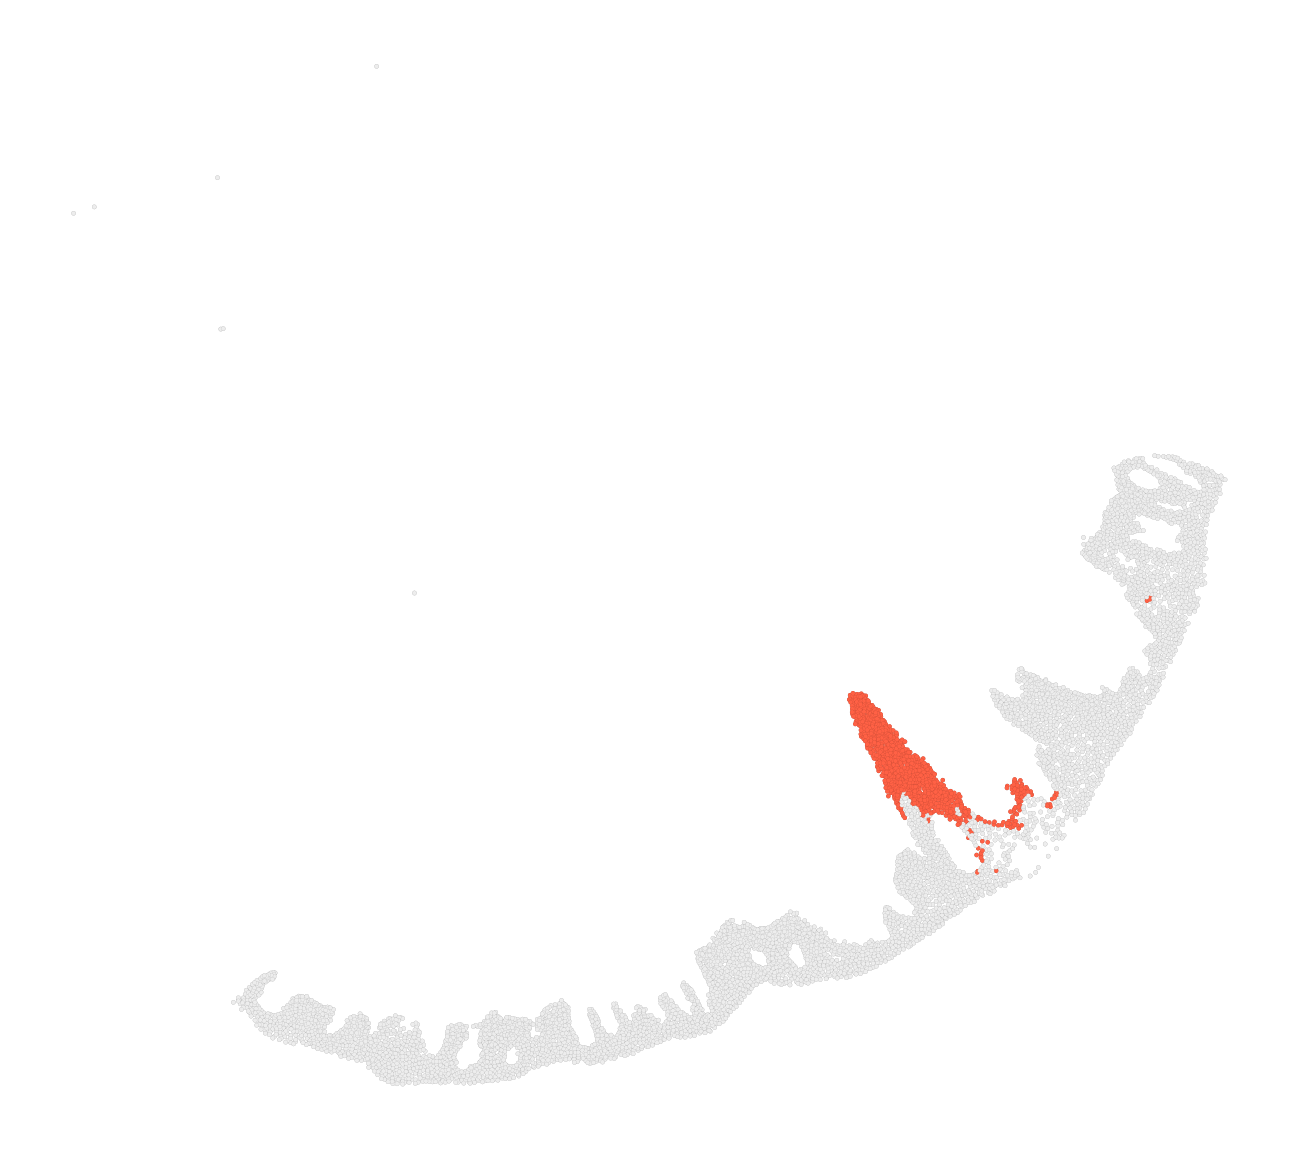

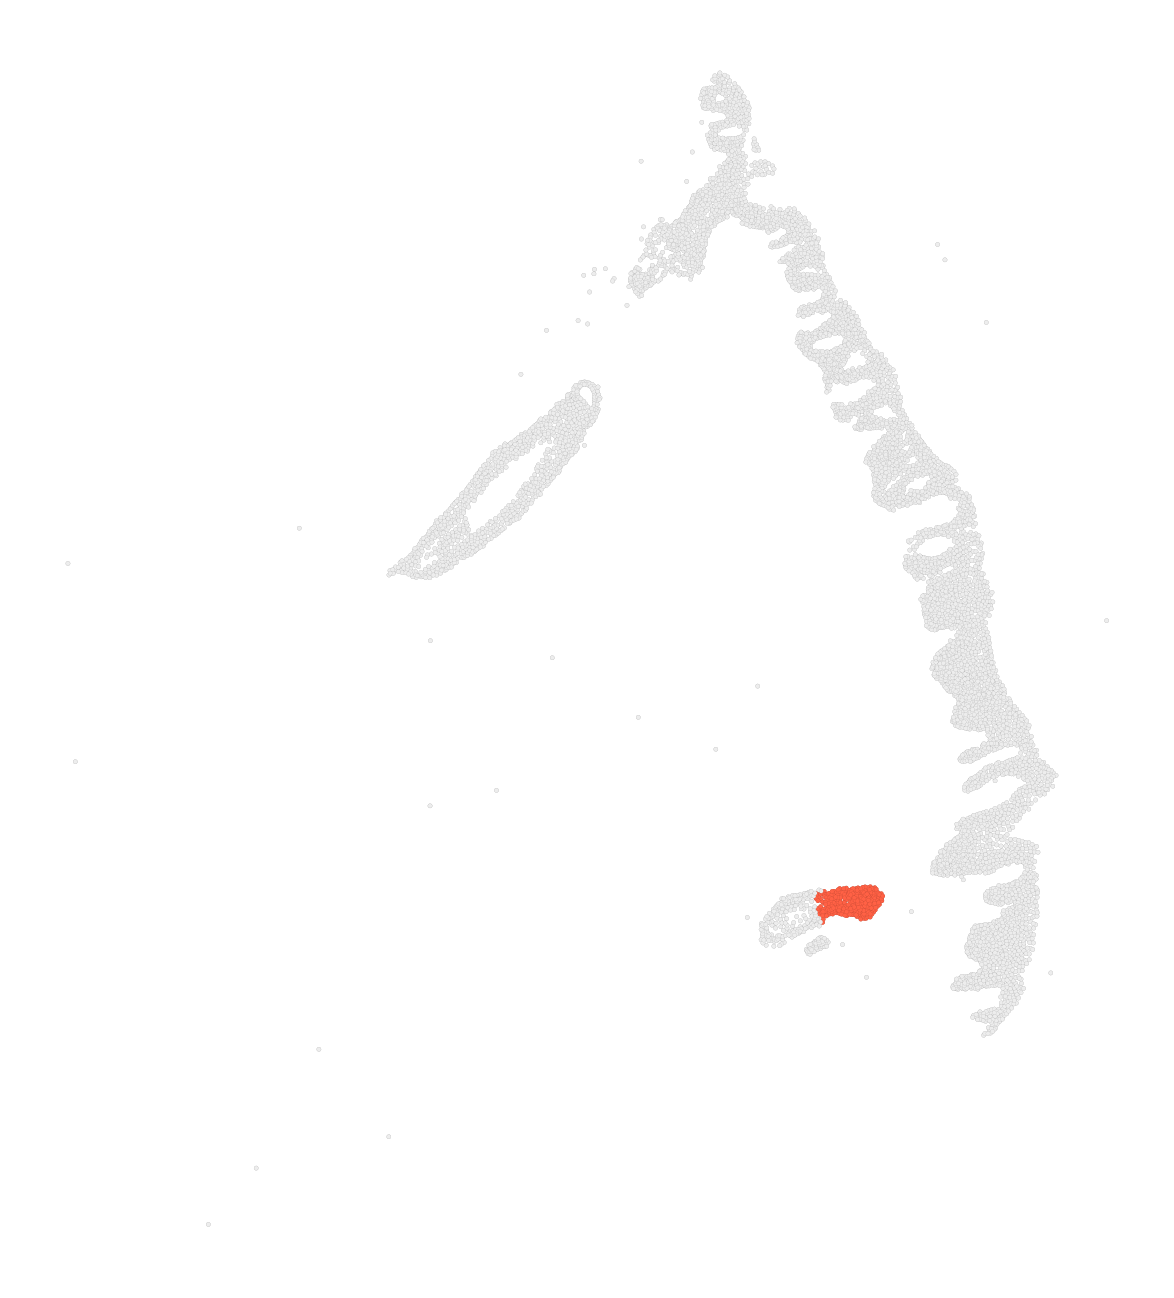

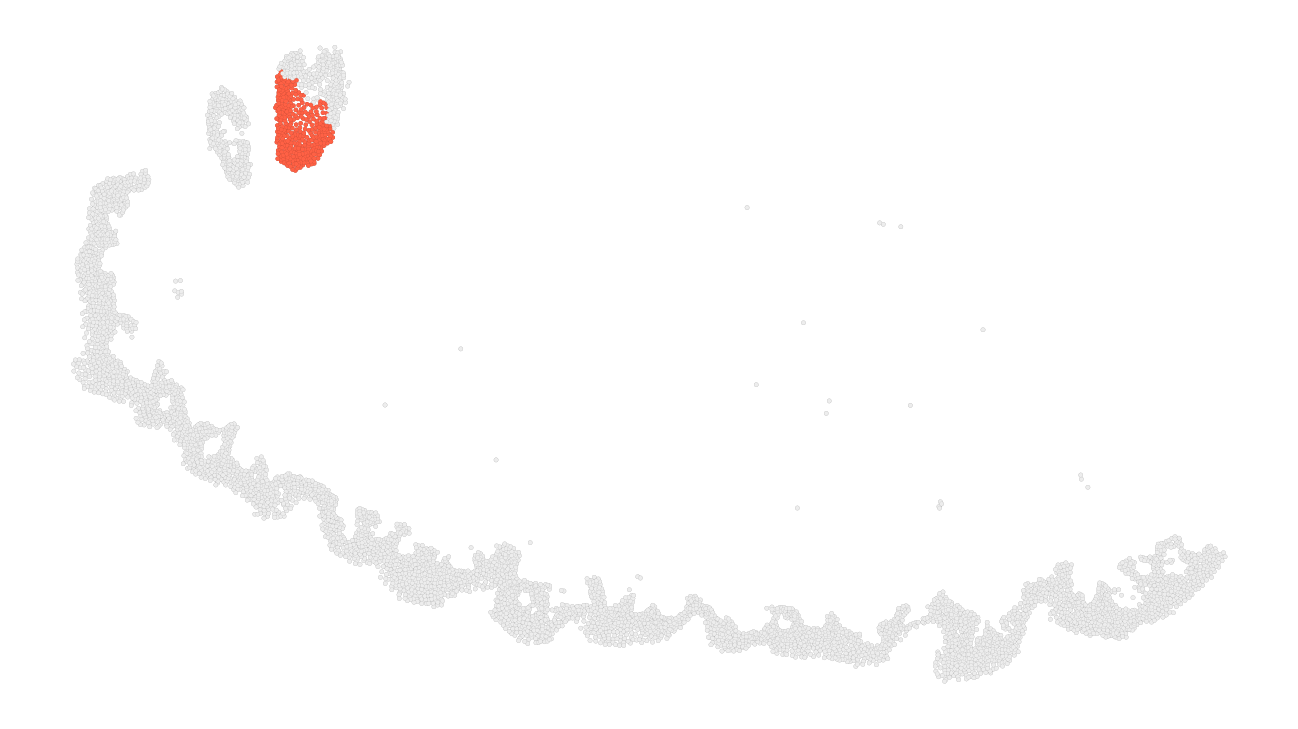

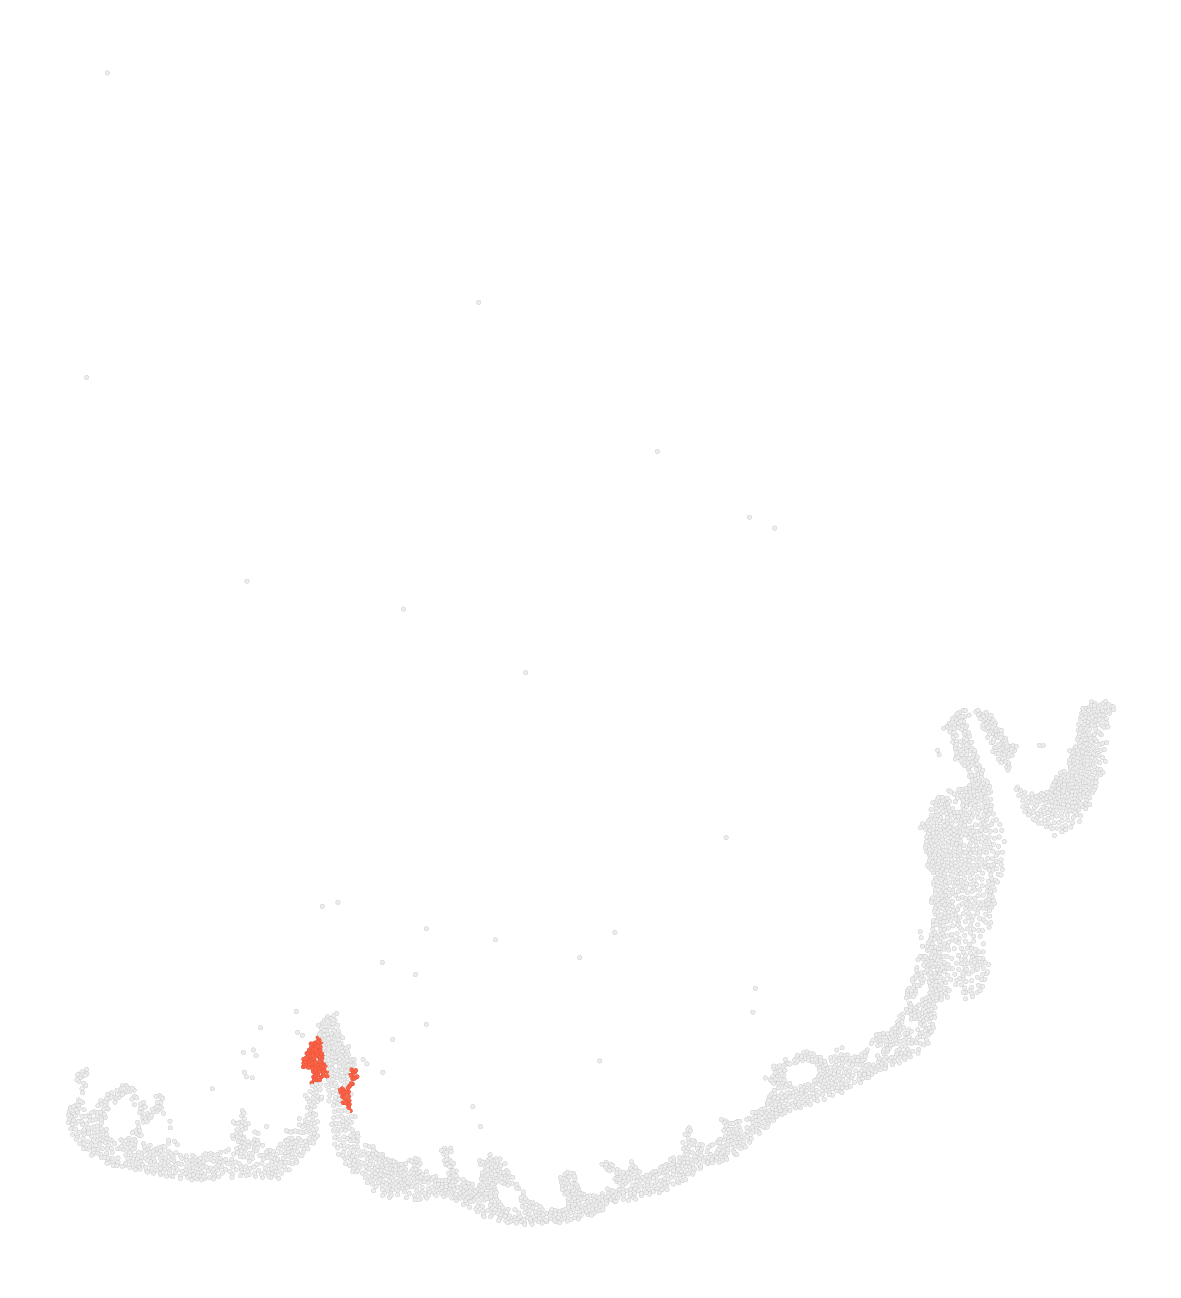

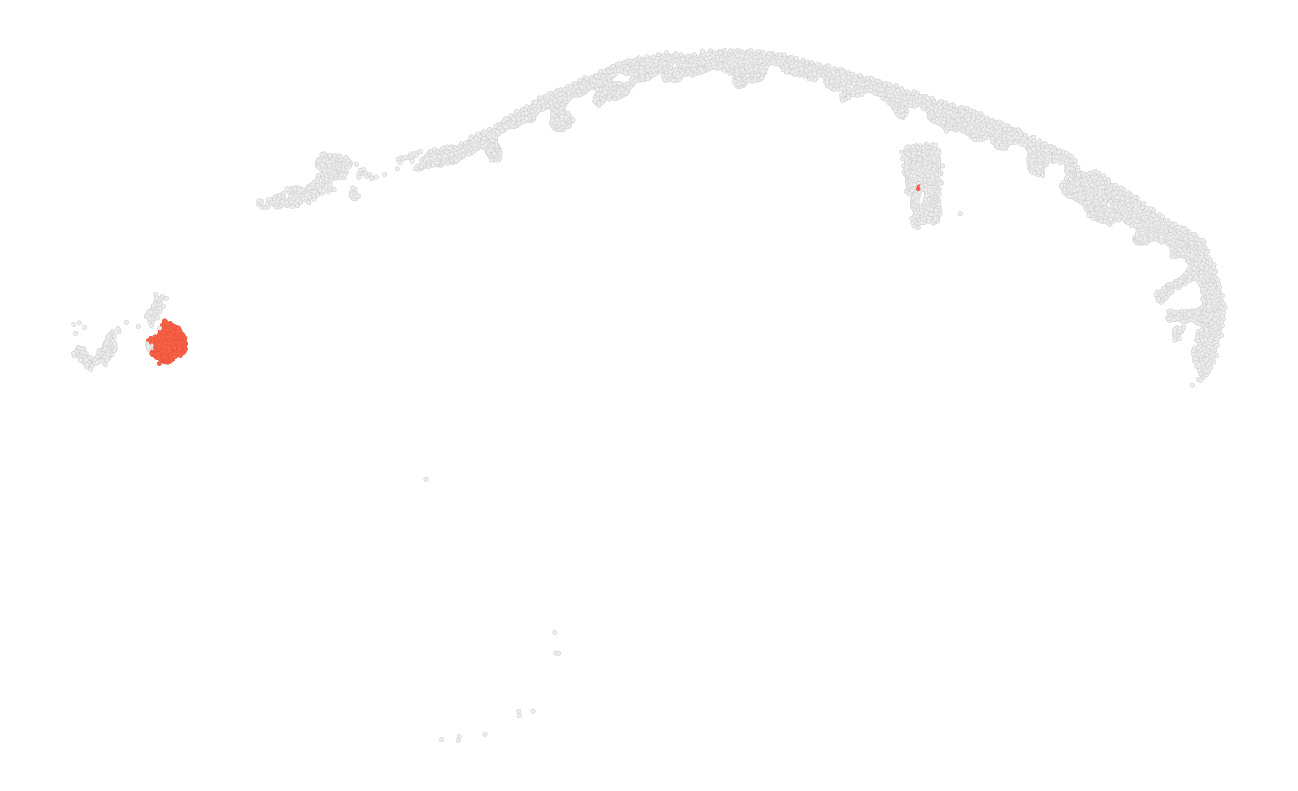

In [11]:
adata_5k_i = adata_5k[(adata_5k.obs["lvl5_annotation"].str.startswith("Seb"))|
                       (adata_5k.obs["lvl5_annotation"].str.startswith("KC"))|
                         (adata_5k.obs["niche19"].str.startswith("Seb"))]
                     
                    
HIGHLIGHT_COLOR = "#ff6145"     # Red, as an example
OTHER_COLOR = "#ededed"         # Very light grey

NICHE="Sebaceous_immune"
#sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18, 18))


#sample_counts = adata_5k_i.obs["info_id6"].value_counts()
#samples_to_keep = sample_counts[sample_counts > 100].index

SEB_SAMPLES = []
for i, DONOR_ID in enumerate(['BK22_Lesional Baseline',
 'Lesional_CE4-SKI-27-FO-4-S22-A2',
 'BK51_wk8 Relapse',
 'BK25_Week 12',  'BK21_Week 12' ]  ):
    adata_i = adata_5k_i[adata_5k_i.obs["info_id6"] == DONOR_ID]
    print(i)
   # print(i+1, "/", len(samples_to_keep))
    STATUS = adata_i.obs["Site_status"].unique()[0]
    TIMEPOINT = adata_i.obs["Timepoint"].unique()[0]
    DONOR = adata_i.obs["Sanger patient ID"].unique()[0]
    INFO_ID = list(adata_i.obs.info_id.unique())[0]
    niche_names_found = adata_i.obs[NICHE_COLUMN].unique()
   
    if NICHE in niche_names_found:
        adata_ii = adata_i[adata_i.obs[NICHE_COLUMN] == NICHE]
        CELL_COUNT = adata_ii.shape[0]
        print("Cell count for slide: ", CELL_COUNT)
        print()
        if CELL_COUNT > 10:
            # 1. Make new obs column
            adata_i.obs[NICHE_COLUMN + "_highlight"] = adata_i.obs[NICHE_COLUMN].apply(
                lambda x: NICHE if x == NICHE else "Other"
            )
            # 2. Force categorical with desired order!
            adata_i.obs[NICHE_COLUMN + "_highlight"] = pd.Categorical(
                adata_i.obs[NICHE_COLUMN + "_highlight"],
                categories=[NICHE, "Other"],
                ordered=True
            )
            # 3. Palette as a list, not a dict
            palette = [HIGHLIGHT_COLOR, OTHER_COLOR]
            from matplotlib.colors import ListedColormap

            palette = ListedColormap([HIGHLIGHT_COLOR, OTHER_COLOR])
            # 4. Plot
            SEB_SAMPLES.append(DONOR_ID)
            print(DONOR_ID)
            sq.pl.spatial_scatter(
                adata_i,
                library_id="spatial",
                shape=None,
                color=NICHE_COLUMN + "_highlight",
                palette=palette,
                size=15,
                vmax=1,
                title='',
                #title=f"{DONOR_ID}_{STATUS}_{TIMEPOINT}_{DONOR}_n={CELL_COUNT}",
                edgecolor='black',
                linewidth=0.02,
                legend_loc=None,
                save=f"4e_sebimmune_nicheonly_{DONOR_ID}.pdf"
                # ax=ax,
                # legend_loc="on data"
            )